# Feature experiment: OSF criterion

Test whether a feature based on tool wear and torque can improve machine-failure prediction.

## Load prepared data

Load the raw train and test features created by the data-preparation step.

In [1]:
import pandas as pd

X_train_raw = pd.read_csv(
    "../data/processed/X_train_raw.csv",
    index_col="record_index",
)
X_test_raw = pd.read_csv(
    "../data/processed/X_test_raw.csv",
    index_col="record_index",
)

y_train = pd.read_csv(
    "../data/processed/y_train.csv",
    index_col="record_index",
).squeeze("columns")
y_test = pd.read_csv(
    "../data/processed/y_test.csv",
    index_col="record_index",
).squeeze("columns")


## Validate the loaded data

Check that feature and target indices still match before creating a new feature.

In [2]:
assert X_train_raw.index.equals(y_train.index)
assert X_test_raw.index.equals(y_test.index)
assert "record_index" not in X_train_raw.columns
assert "record_index" not in X_test_raw.columns

print("Train shape:", X_train_raw.shape)
print("Test shape:", X_test_raw.shape)


Train shape: (8000, 8)
Test shape: (2000, 8)


## Add the OSF criterion

Create the feature from measurements available before a failure occurs. This is an exploratory feature experiment, so the main baseline remains unchanged.

In [3]:
OSF_FEATURE = "OSF criterion"

X_train_osf = X_train_raw.copy()
X_test_osf = X_test_raw.copy()

for X in (X_train_osf, X_test_osf):
    X[OSF_FEATURE] = X["Tool wear [min]"] * X["Torque [Nm]"]

print(X_train_osf[["Tool wear [min]", "Torque [Nm]", OSF_FEATURE]].head())
print("New train shape:", X_train_osf.shape)
print("New test shape:", X_test_osf.shape)


              Tool wear [min]  Torque [Nm]  OSF criterion
record_index                                             
3693                      202         31.5         6363.0
590                       233         36.7         8551.1
6770                       25         40.1         1002.5
1412                      194         53.2        10320.8
3298                       61         38.1         2324.1
New train shape: (8000, 9)
New test shape: (2000, 9)


## Prepare feature variants

Create a baseline dataset and a dataset with the additional OSF criterion.

In [4]:
BASE_FEATURES = X_train_raw.columns.tolist()

X_train_baseline = X_train_raw.copy()
X_test_baseline = X_test_raw.copy()

X_train_baseline = X_train_raw.copy()
X_test_baseline = X_test_raw.copy()

# Reuse the OSF feature created above; do not mutate the baseline frames.
X_train_osf = X_train_raw.copy()
X_test_osf = X_test_raw.copy()
X_train_osf[OSF_FEATURE] = X_train_osf["Tool wear [min]"] * X_train_osf["Torque [Nm]"]
X_test_osf[OSF_FEATURE] = X_test_osf["Tool wear [min]"] * X_test_osf["Torque [Nm]"]

print("Baseline features:", X_train_baseline.shape[1])
print("OSF experiment features:", X_train_osf.shape[1])
assert X_train_baseline.columns.tolist() == BASE_FEATURES
assert OSF_FEATURE not in X_train_baseline.columns
assert OSF_FEATURE in X_train_osf.columns
assert "record_index" not in X_train_baseline.columns
assert "record_index" not in X_train_osf.columns

print("New feature:", OSF_FEATURE in X_train_osf.columns)

Baseline features: 8
OSF experiment features: 9
New feature: True


## Create stratified cross-validation splits



Use the same class proportions in every validation fold.

In [5]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold_number, (train_indices, validation_indices) in enumerate(cv.split(X_train_baseline, y_train), start = 1):
    y_fold_train = y_train.iloc[train_indices]
    y_fold_validation = y_train.iloc[validation_indices]

    print(
        f"Fold {fold_number}: "
        f"train={len(train_indices)}, "
        f"validation={len(validation_indices)}, "
        f"failures in train={y_fold_train.sum()}, "
        f"failures in validation={y_fold_validation.sum()}"
    )

Fold 1: train=6400, validation=1600, failures in train=212, failures in validation=52
Fold 2: train=6400, validation=1600, failures in train=211, failures in validation=53
Fold 3: train=6400, validation=1600, failures in train=211, failures in validation=53
Fold 4: train=6400, validation=1600, failures in train=211, failures in validation=53
Fold 5: train=6400, validation=1600, failures in train=211, failures in validation=53


## Define models and evaluation metrics

In [6]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        class_weight='balanced',
        n_estimators=200,
        random_state=42,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42,
    ),
}


## Evaluate models with cross-validation

In [7]:
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler

DECISION_THRESHOLD = 0.5
CATEGORICAL_FEATURES = ["Type_L", "Type_M"]

def prepare_fold_data(X_train_fold, X_validation_fold):
    """
    Scale numeric features using only the training part of one fold.
    """
    X_train_fold = X_train_fold.copy()
    X_validation_fold = X_validation_fold.copy()

    numeric_features = [
        column
        for column in X_train_fold.columns
        if column not in CATEGORICAL_FEATURES
    ]

    scaler = StandardScaler()

    X_train_fold[numeric_features] = scaler.fit_transform(X_train_fold[numeric_features])
    X_validation_fold[numeric_features] = scaler.transform(X_validation_fold[numeric_features])

    return X_train_fold, X_validation_fold

def get_metrics(y_true, y_proba):
    y_pred = (y_proba >= DECISION_THRESHOLD).astype(int)

    return {
        "accuracy": (y_true == y_pred).mean(),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

def evaluate_model_with_cv(model, X, y, cv):
    """
    Evaluate one model across all cross-validation folds.
    """
    fold_metrics = []

    for train_indices, validation_indices in cv.split(X, y):
        X_train_fold = X.iloc[train_indices]
        X_validation_fold = X.iloc[validation_indices]

        y_train_fold = y.iloc[train_indices]
        y_validation_fold = y.iloc[validation_indices]

        X_train_fold, X_validation_fold = prepare_fold_data(X_train_fold, X_validation_fold)

        fold_model = clone(model)
        fold_model.fit(X_train_fold, y_train_fold)
        y_proba = fold_model.predict_proba(X_validation_fold)[:, 1]

        metrics = get_metrics(y_validation_fold, y_proba)
        metrics["fold"] = len(fold_metrics) + 1
        fold_metrics.append(metrics)

    fold_metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
    summary = {}
    for metric in fold_metrics_df.columns:
        summary[f"{metric}_mean"] = fold_metrics_df[metric].mean()
        summary[f"{metric}_std"] = fold_metrics_df[metric].std()

    return summary, fold_metrics_df

## Compare feature variants

Compare baseline features with the baseline plus OSF criterion using the same folds and decision threshold.

In [8]:
feature_variants = {
    "Baseline": X_train_baseline,
    "Baseline + OSF criterion": X_train_osf,
}

comparison_rows = []
fold_results = {}

for feature_variant, X_features in feature_variants.items():
    for model_name, model in models.items():
        summary, fold_metrics = evaluate_model_with_cv(model, X_features, y_train, cv)
        fold_results[(feature_variant, model_name)] = fold_metrics
        comparison_rows.append({
            "feature_variant": feature_variant,
            "model": model_name,
            **summary,
        })

comparison_results = pd.DataFrame(comparison_rows)
comparison_results.sort_values("f1_mean", ascending=False) 

,feature_variant,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
5,Baseline + OSF criterion,Gradient Boosting,0.993625,0.002437,0.965071,0.046764,0.840929,0.085997,0.895381,0.045543,0.990881,0.010406,0.925832,0.039817
4,Baseline + OSF criterion,Random Forest,0.991125,0.001355,0.883297,0.060813,0.852467,0.093520,0.862151,0.030494,0.989108,0.009275,0.911670,0.047644
2,Baseline,Gradient Boosting,0.990250,0.002404,0.912231,0.014711,0.780479,0.085597,0.838810,0.049545,0.992867,0.005465,0.912056,0.035882
1,Baseline,Random Forest,0.989375,0.002073,0.875500,0.041057,0.795718,0.093292,0.829713,0.043474,0.988805,0.006628,0.881092,0.051841
3,Baseline + OSF criterion,Logistic Regression,0.860250,0.012606,0.171323,0.005607,0.840856,0.071494,0.284331,0.007837,0.937880,0.015283,0.483356,0.093088
0,Baseline,Logistic Regression,0.863250,0.010378,0.171179,0.003786,0.818215,0.080613,0.282815,0.007933,0.934528,0.016697,0.506032,0.101980


## Compare confusion matrices

Inspect out-of-fold classification errors for each model and feature variant.

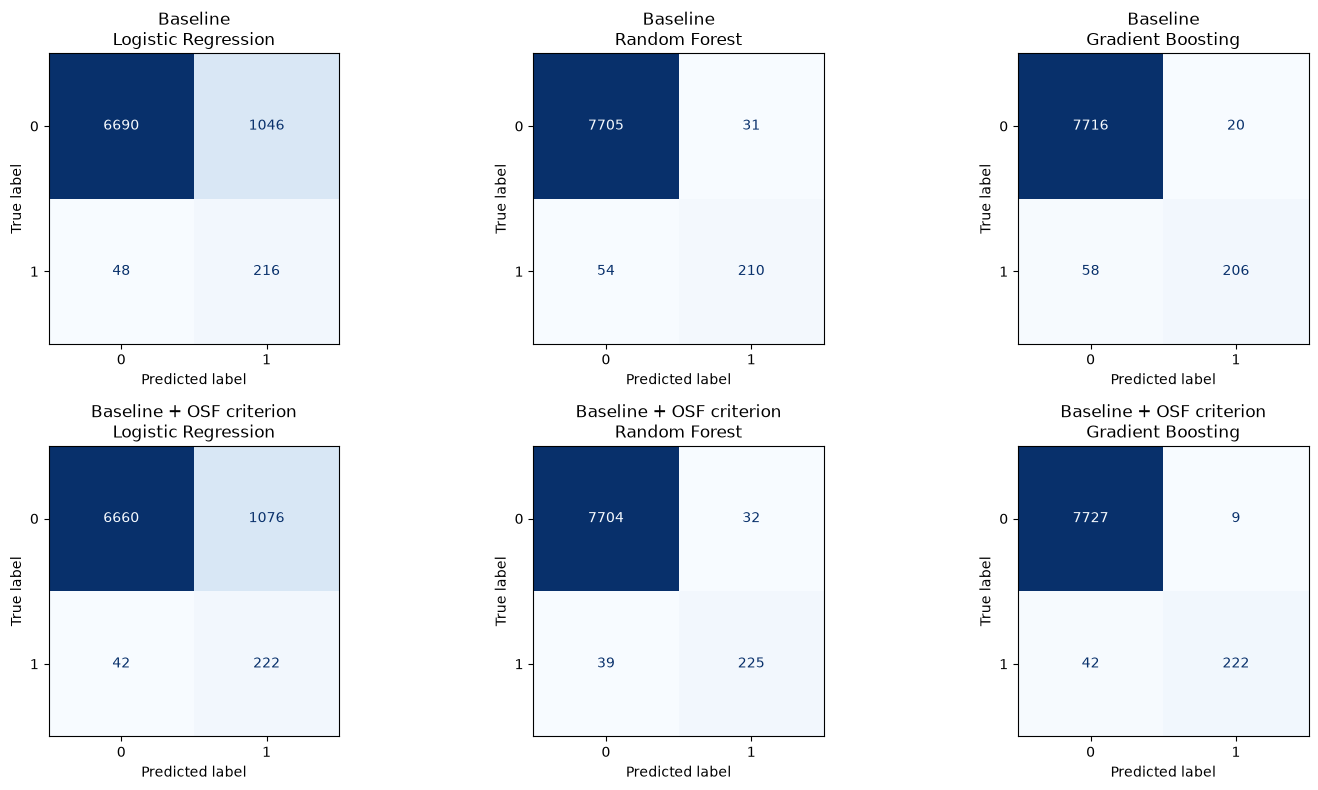

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def get_oof_predictions(model, X, y, cv):
    y_true_all = []
    y_pred_all = []

    for train_indices, validation_indices in cv.split(X, y):
        X_train_fold = X.iloc[train_indices]
        X_validation_fold = X.iloc[validation_indices]
        y_train_fold = y.iloc[train_indices]
        y_validation_fold = y.iloc[validation_indices]

        X_train_fold, X_validation_fold = prepare_fold_data(
            X_train_fold, X_validation_fold
        )
        fold_model = clone(model)
        fold_model.fit(X_train_fold, y_train_fold)
        y_proba = fold_model.predict_proba(X_validation_fold)[:, 1]
        y_pred = (y_proba >= DECISION_THRESHOLD).astype(int)

        y_true_all.extend(y_validation_fold)
        y_pred_all.extend(y_pred)

    return y_true_all, y_pred_all

fig, axes = plt.subplots(2, len(models), figsize=(15, 8))

for row, (feature_variant, X_features) in enumerate(feature_variants.items()):
    for column, (model_name, model) in enumerate(models.items()):
        y_true_oof, y_pred_oof = get_oof_predictions(model, X_features, y_train, cv)
        matrix = confusion_matrix(y_true_oof, y_pred_oof)
        ConfusionMatrixDisplay(matrix, display_labels=[0, 1]).plot(
            ax=axes[row, column],
            cmap="Blues",
            colorbar=False,
        )
        axes[row, column].set_title(f"{feature_variant}\n{model_name}")

plt.tight_layout()
plt.show()

## Results and summary

The confusion matrices show aggregated out-of-fold predictions from 5-fold cross-validation for 8,000 training records. Rows represent the true class and columns represent the class predicted by the model.

| Wariant cech | Model | TN | FP | FN | TP |
|---|---|---:|---:|---:|---:|
| Baseline | Logistic Regression | 6690 | 1046 | 48 | 216 |
| Baseline | Random Forest | 7705 | 31 | 54 | 210 |
| Baseline | Gradient Boosting | 7716 | 20 | 58 | 206 |
| Baseline + OSF criterion | Logistic Regression | 6660 | 1076 | 42 | 222 |
| Baseline + OSF criterion | Random Forest | 7704 | 32 | 39 | 225 |
| Baseline + OSF criterion | Gradient Boosting | 7727 | 9 | 42 | 222 |

### Interpretation

- **Logistic Regression:** OSF detected 6 additional failures and reduced false negatives from 48 to 42, but increased false positives from 1,046 to 1,076.
- **Random Forest:** OSF reduced missed failures from 54 to 39, with only a small increase in false positives from 31 to 32.
- **Gradient Boosting:** OSF improved both important error types: false negatives decreased from 58 to 42, while false positives decreased from 20 to 9.

### Conclusion

The most promising combination is **Baseline + OSF criterion + Gradient Boosting**. Compared with the baseline, it detects more failures and generates fewer false alarms. The OSF feature also appears beneficial for Random Forest. Logistic Regression still produces many false alarms, making it less practical with the current `probability >= 0.5` decision rule.

These results are used to select the experimental variant. They are not yet a final evaluation on an independent, untouched test set.

## Analyze decision thresholds and errors

Use out-of-fold probabilities to compare decision thresholds and inspect false positives and false negatives.

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score

def get_oof_probabilities(model, X, y, cv):
    y_proba_oof = pd.Series(index=X.index, dtype=float, name="y_proba")

    for train_indices, validation_indices in cv.split(X, y):
        X_train_fold = X.iloc[train_indices]
        X_validation_fold = X.iloc[validation_indices]
        y_train_fold = y.iloc[train_indices]

        X_train_fold, X_validation_fold = prepare_fold_data(
            X_train_fold, X_validation_fold
        )
        fold_model = clone(model)
        fold_model.fit(X_train_fold, y_train_fold)
        y_proba_oof.iloc[validation_indices] = fold_model.predict_proba(
            X_validation_fold
        )[:, 1]

    return y_proba_oof

def evaluate_thresholds(y_true, y_proba, thresholds):
    rows = []
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        rows.append({
            "threshold": threshold,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "false_positives": ((y_true == 0) & (y_pred == 1)).sum(),
            "false_negatives": ((y_true == 1) & (y_pred == 0)).sum(),
        })
    return pd.DataFrame(rows)

thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
oof_probabilities = {}
threshold_results = []

for feature_variant, X_features in feature_variants.items():
    for model_name, model in models.items():
        key = (feature_variant, model_name)
        y_proba = get_oof_probabilities(model, X_features, y_train, cv)
        oof_probabilities[key] = y_proba
        metrics_by_threshold = evaluate_thresholds(y_train, y_proba, thresholds)
        metrics_by_threshold.insert(0, "model", model_name)
        metrics_by_threshold.insert(0, "feature_variant", feature_variant)
        threshold_results.append(metrics_by_threshold)

threshold_results = pd.concat(threshold_results, ignore_index=True)
display(threshold_results)

,feature_variant,model,threshold,precision,recall,f1,false_positives,false_negatives
0,Baseline,Logistic Regression,0.2,0.090199,0.962121,0.164935,2562,10
1,Baseline,Logistic Regression,0.3,0.115366,0.924242,0.205128,1871,20
2,Baseline,Logistic Regression,0.4,0.139349,0.859848,0.239831,1402,37
3,Baseline,Logistic Regression,0.5,0.171157,0.818182,0.283093,1046,48
4,Baseline,Logistic Regression,0.6,0.213415,0.795455,0.336538,774,54
5,Baseline,Logistic Regression,0.7,0.264075,0.746212,0.390099,549,67
6,Baseline,Logistic Regression,0.8,0.339114,0.666667,0.449553,343,88
7,Baseline,Random Forest,0.2,0.505400,0.886364,0.643741,229,30
8,Baseline,Random Forest,0.3,0.680723,0.856061,0.758389,106,38
9,Baseline,Random Forest,0.4,0.802920,0.833333,0.817844,54,44


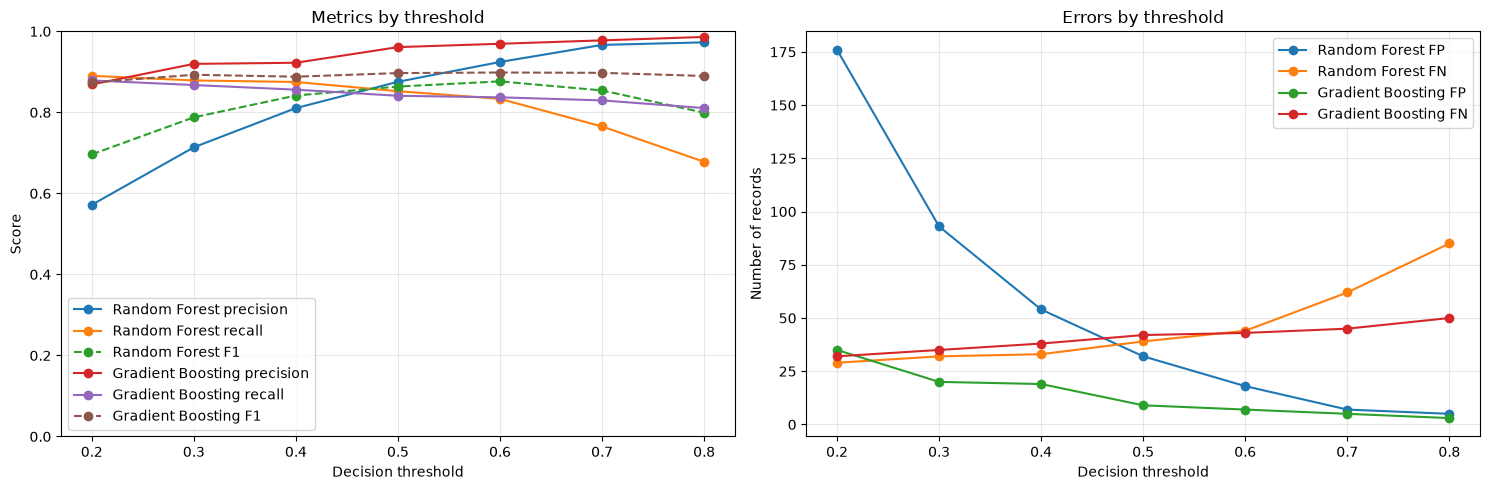

,y_true,y_proba,y_pred,error_type,Type_L,Type_M,Process temperature [K],Temperature difference,Rotational speed [rpm],Torque [Nm],Power [W],Tool wear [min]
record_index,,,,,,,,,,,,
9174,1,0.000721,0,FN,1,0,308.9,11.1,1871,25.6,5015.82,200
1996,1,0.000777,0,FN,0,1,308.0,9.6,1416,38.2,5664.42,198
2244,1,0.006471,0,FN,0,1,308.4,9.1,1542,37.5,6055.42,203
8357,1,0.006857,0,FN,1,0,309.5,11.0,1385,46.3,6715.21,203
9576,1,0.007178,0,FN,1,0,310.7,11.1,1922,23.3,4689.62,205
7849,1,0.013424,0,FN,0,1,311.7,11.4,1374,47.9,6892.09,222
6419,1,0.013637,0,FN,0,0,309.9,9.6,1394,46.7,6817.24,210
1087,1,0.014569,0,FN,0,0,307.8,10.9,1549,35.8,5807.15,206
5309,1,0.016403,0,FN,0,1,313.2,9.3,1422,48.0,7147.75,215


In [11]:
import matplotlib.pyplot as plt

best_variant = "Baseline + OSF criterion"
models_to_plot = ["Random Forest", "Gradient Boosting"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for model_name in models_to_plot:
    selection = (
        (threshold_results["feature_variant"] == best_variant)
        & (threshold_results["model"] == model_name)
    )
    model_thresholds = threshold_results[selection]
    axes[0].plot(model_thresholds["threshold"], model_thresholds["precision"], marker="o", label=f"{model_name} precision")
    axes[0].plot(model_thresholds["threshold"], model_thresholds["recall"], marker="o", label=f"{model_name} recall")
    axes[0].plot(model_thresholds["threshold"], model_thresholds["f1"], marker="o", linestyle="--", label=f"{model_name} F1")
    axes[1].plot(model_thresholds["threshold"], model_thresholds["false_positives"], marker="o", label=f"{model_name} FP")
    axes[1].plot(model_thresholds["threshold"], model_thresholds["false_negatives"], marker="o", label=f"{model_name} FN")

axes[0].set(title="Metrics by threshold", xlabel="Decision threshold", ylabel="Score", ylim=(0, 1))
axes[1].set(title="Errors by threshold", xlabel="Decision threshold", ylabel="Number of records")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

def get_error_records(feature_variant, model_name, threshold=0.5):
    y_proba = oof_probabilities[(feature_variant, model_name)]
    error_table = pd.DataFrame({
        "y_true": y_train,
        "y_proba": y_proba,
    })
    error_table["y_pred"] = (error_table["y_proba"] >= threshold).astype(int)
    error_table["error_type"] = "correct"
    error_table.loc[(error_table.y_true == 0) & (error_table.y_pred == 1), "error_type"] = "FP"
    error_table.loc[(error_table.y_true == 1) & (error_table.y_pred == 0), "error_type"] = "FN"
    errors = error_table[error_table["error_type"].isin(["FP", "FN"])].copy()
    return errors.join(X_train_raw, how="left", rsuffix="_raw")

selected_errors = get_error_records(best_variant, "Gradient Boosting", threshold=0.5)
display(selected_errors.sort_values(["error_type", "y_proba"]))

In [12]:
cost_scenarios = {
    "Equal costs": {"cost_fp": 1, "cost_fn": 1},
    "FN five times more expensive": {"cost_fp": 1, "cost_fn": 5},
    "FN ten times more expensive": {"cost_fp": 1, "cost_fn": 10},
}

cost_results = threshold_results.copy()
for scenario_name, costs in cost_scenarios.items():
    cost_results[scenario_name] = (
        cost_results["false_positives"] * costs["cost_fp"]
        + cost_results["false_negatives"] * costs["cost_fn"]
    )

selected_model_results = cost_results[
    (cost_results["feature_variant"] == best_variant)
    & (cost_results["model"] == "Gradient Boosting")
].copy()
display(selected_model_results)

for scenario_name in cost_scenarios:
    best_row = selected_model_results.loc[selected_model_results[scenario_name].idxmin()]
    print(f"{scenario_name}: best threshold = {best_row['threshold']:.2f}, total cost = {best_row[scenario_name]:.0f}")

,feature_variant,model,threshold,precision,recall,f1,false_positives,false_negatives,Equal costs,FN five times more expensive,FN ten times more expensive
35,Baseline + OSF criterion,Gradient Boosting,0.2,0.868914,0.878788,0.873823,35,32,67,195,355
36,Baseline + OSF criterion,Gradient Boosting,0.3,0.919679,0.867424,0.892788,20,35,55,195,370
37,Baseline + OSF criterion,Gradient Boosting,0.4,0.922449,0.856061,0.888016,19,38,57,209,399
38,Baseline + OSF criterion,Gradient Boosting,0.5,0.961039,0.840909,0.896970,9,42,51,219,429
39,Baseline + OSF criterion,Gradient Boosting,0.6,0.969298,0.837121,0.898374,7,43,50,222,437
40,Baseline + OSF criterion,Gradient Boosting,0.7,0.977679,0.829545,0.897541,5,45,50,230,455
41,Baseline + OSF criterion,Gradient Boosting,0.8,0.986175,0.810606,0.889813,3,50,53,253,503


Equal costs: best threshold = 0.60, total cost = 50
FN five times more expensive: best threshold = 0.20, total cost = 195
FN ten times more expensive: best threshold = 0.20, total cost = 355


### How to read the threshold analysis

- `threshold_results` compares decision thresholds. Lowering the threshold usually increases recall and decreases false negatives, but it also increases false positives.
- The first plot shows precision, recall, and F1. The second plot shows the number of false positives and false negatives.
- `selected_errors` contains the individual records classified incorrectly for the selected model and threshold. `error_type = FP` means a false alarm; `error_type = FN` means a missed failure.
- `y_proba` is the model probability for class 1. Records close to the threshold are borderline cases and are especially useful for inspection.
- `cost_results` combines FP and FN counts using assumed costs. The assumptions are examples, not measured business costs. The best threshold is the one with the lowest total cost under the selected scenario.

## Check stability across cross-validation folds

Compare fold-level metrics to see whether the OSF improvement is consistent or driven by a single fold.

In [13]:
fold_stability_rows = []

for (feature_variant, model_name), fold_metrics in fold_results.items():
    fold_table = fold_metrics.reset_index()
    fold_table.insert(0, "model", model_name)
    fold_table.insert(0, "feature_variant", feature_variant)
    fold_stability_rows.append(fold_table)

fold_stability_results = pd.concat(fold_stability_rows, ignore_index=True)
display(fold_stability_results)

stability_summary = (
    fold_stability_results
    .groupby(["feature_variant", "model"])[["precision", "recall", "f1", "pr_auc", "accuracy"]]
    .agg(["mean", "std", "min", "max"])
)
display(stability_summary)

,feature_variant,model,fold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Baseline,Logistic Regression,1,0.869375,0.176955,0.826923,0.291525,0.938655,0.401851
1,Baseline,Logistic Regression,2,0.860000,0.167315,0.811321,0.277419,0.918906,0.528122
2,Baseline,Logistic Regression,3,0.858750,0.168582,0.830189,0.280255,0.943787,0.564101
3,Baseline,Logistic Regression,4,0.850625,0.172535,0.924528,0.290801,0.955215,0.633363
4,Baseline,Logistic Regression,5,0.877500,0.170507,0.698113,0.274074,0.916076,0.402721
5,Baseline,Random Forest,1,0.991250,0.865385,0.865385,0.865385,0.992043,0.908123
6,Baseline,Random Forest,2,0.989375,0.928571,0.735849,0.821053,0.982248,0.855780
7,Baseline,Random Forest,3,0.988750,0.818182,0.849057,0.833333,0.996158,0.928194
8,Baseline,Random Forest,4,0.991250,0.867925,0.867925,0.867925,0.992267,0.911309
9,Baseline,Random Forest,5,0.986250,0.897436,0.660377,0.760870,0.981309,0.802054


precision                      \
                                                  mean       std       min   
feature_variant          model                                               
Baseline                 Gradient Boosting    0.912231  0.014711  0.895833   
                         Logistic Regression  0.171179  0.003786  0.167315   
                         Random Forest        0.875500  0.041057  0.818182   
Baseline + OSF criterion Gradient Boosting    0.965071  0.046764  0.886792   
                         Logistic Regression  0.171323  0.005607  0.164430   
                         Random Forest        0.883297  0.060813  0.816667   

                                                          recall            \
                                                   max      mean       std   
feature_variant          model                                               
Baseline                 Gradient Boosting    0.933333  0.780479  0.085597   
                         Logistic Regression  0.176955  0.818215  0.080613   
                         Random Forest        0.928571  0.795718  0.093292   
Baseline + OSF criterion Gradient Boosting    1.000000  0.840929  0.085997   
                         Logistic Regression  0.179916  0.840856  0.071494   
                         Random Forest        0.973684  0.852467  0.093520   

                                                                        f1  \
                                                   min       max      mean   
feature_variant          model                                               
Baseline                 Gradient Boosting    0.641509  0.867925  0.838810   
                         Logistic Regression  0.698113  0.924528  0.282815   
                         Random Forest        0.660377  0.867925  0.829713   
Baseline + OSF criterion Gradient Boosting    0.698113  0.924528  0.895381   
                         Logistic Regression  0.735849  0.924528  0.284331   
                         Random Forest        0.698113  0.924528  0.862151   

                                                                            \
                                                   std       min       max   
feature_variant          model                                               
Baseline                 Gradient Boosting    0.049545  0.755556  0.884615   
                         Logistic Regression  0.007933  0.274074  0.291525   
                         Random Forest        0.043474  0.760870  0.867925   
Baseline + OSF criterion Gradient Boosting    0.045543  0.822222  0.942308   
                         Logistic Regression  0.007837  0.275618  0.295533   
                         Random Forest        0.030494  0.813187  0.897196   

                                                pr_auc                      \
                                                  mean       std       min   
feature_variant          model                                               
Baseline                 Gradient Boosting    0.912056  0.035882  0.862171   
                         Logistic Regression  0.506032  0.101980  0.401851   
                         Random Forest        0.881092  0.051841  0.802054   
Baseline + OSF criterion Gradient Boosting    0.925832  0.039817  0.867038   
                         Logistic Regression  0.483356  0.093088  0.376073   
                         Random Forest        0.911670  0.047644  0.838500   

                                                        accuracy            \
                                                   max      mean       std   
feature_variant          model                                               
Baseline                 Gradient Boosting    0.940453  0.990250  0.002404   
                         Logistic Regression  0.633363  0.863250  0.010378   
                         Random Forest        0.928194  0.989375  0.002073   
Baseline + OSF criterion Gradient Boosting    0.972662  0.9936

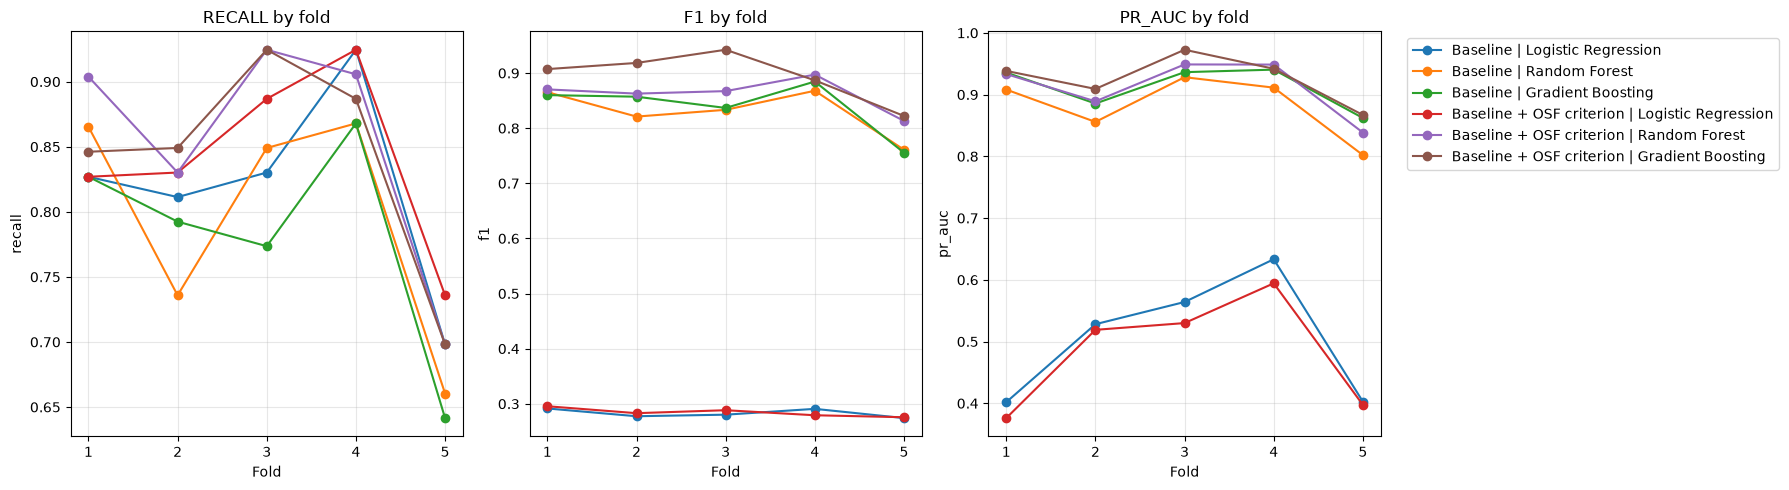

In [14]:
import matplotlib.pyplot as plt

metrics_to_plot = ["recall", "f1", "pr_auc"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 5))

for ax, metric in zip(axes, metrics_to_plot):
    for (feature_variant, model_name), fold_metrics in fold_results.items():
        label = f"{feature_variant} | {model_name}"
        ax.plot(
            fold_metrics.index,
            fold_metrics[metric],
            marker="o",
            label=label,
        )
    ax.set_title(f"{metric.upper()} by fold")
    ax.set_xlabel("Fold")
    ax.set_ylabel(metric)
    ax.set_xticks(range(1, cv.n_splits + 1))
    ax.grid(alpha=0.3)

axes[-1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Fold stability summary

Fold 5 was more difficult for several models, not only for Gradient Boosting with the OSF feature. This suggests that the fold contains harder failure cases rather than showing a problem specific to one model or feature. Cross-validation therefore gives us both an average expected performance and an indication of how much performance can vary across data subsets.

For genuinely new data, this conclusion is valid only if the new records come from a similar data-generating process. A change in machines, operating conditions, or failure patterns can reduce performance. An independent future dataset would be needed to verify generalization under real deployment conditions.

## Evaluate the selected model on X_test

Train Gradient Boosting with the OSF criterion on all training records and evaluate it once on `X_test`. The scaler is fitted only on the training data.

accuracy            0.994500
precision           0.982456
recall              0.848485
f1                  0.910569
roc_auc             0.995276
pr_auc              0.935651
false_positives     1.000000
false_negatives    10.000000
Name: Gradient Boosting + OSF on X_test, dtype: float64

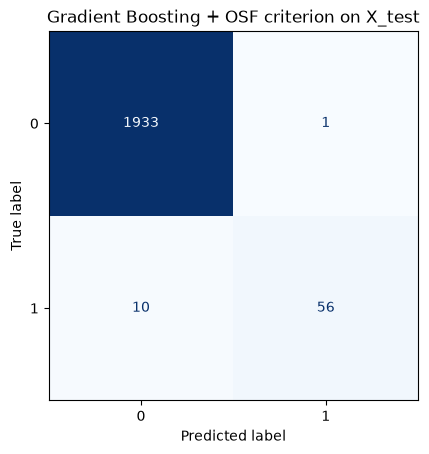

In [15]:
FINAL_THRESHOLD = 0.5
FINAL_FEATURES = X_train_osf.columns.tolist()

X_train_final = X_train_osf[FINAL_FEATURES].copy()
X_test_final = X_test_osf[FINAL_FEATURES].copy()
numeric_features = [column for column in FINAL_FEATURES if column not in CATEGORICAL_FEATURES]

final_scaler = StandardScaler()
X_train_final[numeric_features] = final_scaler.fit_transform(X_train_final[numeric_features])
X_test_final[numeric_features] = final_scaler.transform(X_test_final[numeric_features])

final_model = GradientBoostingClassifier(random_state=42)
final_model.fit(X_train_final, y_train)
final_y_proba = final_model.predict_proba(X_test_final)[:, 1]
final_y_pred = (final_y_proba >= FINAL_THRESHOLD).astype(int)

final_metrics = get_metrics(y_test, final_y_proba)
final_metrics["false_positives"] = ((y_test == 0) & (final_y_pred == 1)).sum()
final_metrics["false_negatives"] = ((y_test == 1) & (final_y_pred == 0)).sum()
display(pd.Series(final_metrics, name="Gradient Boosting + OSF on X_test"))

final_confusion_matrix = confusion_matrix(y_test, final_y_pred)
ConfusionMatrixDisplay(
    final_confusion_matrix,
    display_labels=[0, 1],
).plot(cmap="Blues", colorbar=False)
plt.title("Gradient Boosting + OSF criterion on X_test")
plt.show()

### False positives and false negatives on X_test

The following table identifies the test records misclassified by the selected model. Because the current test split was already inspected during earlier experimentation, these results should be treated as a final development check rather than a completely untouched external validation.

In [16]:
final_errors = pd.DataFrame({
    "y_true": y_test,
    "y_proba": final_y_proba,
    "y_pred": final_y_pred,
})
final_errors["error_type"] = "correct"
final_errors.loc[(final_errors.y_true == 0) & (final_errors.y_pred == 1), "error_type"] = "FP"
final_errors.loc[(final_errors.y_true == 1) & (final_errors.y_pred == 0), "error_type"] = "FN"
final_errors = final_errors[final_errors["error_type"].isin(["FP", "FN"])].copy()
final_errors = final_errors.join(X_test_raw, how="left", rsuffix="_raw")
display(final_errors.sort_values(["error_type", "y_proba"]))

,y_true,y_proba,y_pred,error_type,Type_L,Type_M,Process temperature [K],Temperature difference,Rotational speed [rpm],Torque [Nm],Power [W],Tool wear [min]
record_index,,,,,,,,,,,,
2941,1,0.021120,0,FN,0,1,309.6,8.9,1996,19.8,4138.61,203
6924,1,0.023047,0,FN,1,0,311.6,10.4,1461,52.9,8093.47,208
8609,1,0.030928,0,FN,1,0,308.3,10.9,1475,40.5,6255.70,222
7510,1,0.050026,0,FN,1,0,311.8,11.3,1524,38.9,6208.16,214
9018,1,0.052882,0,FN,1,0,308.1,10.8,1615,35.4,5986.93,217
4034,1,0.058866,0,FN,1,0,310.8,8.8,1615,29.0,4904.55,235
9758,1,0.068554,0,FN,1,0,309.8,11.2,2271,16.2,3852.66,218
8199,1,0.135419,0,FN,1,0,310.7,11.5,1737,27.0,4911.25,225
3760,1,0.434471,0,FN,1,0,310.9,8.6,1377,46.8,6748.52,166


## Final test conclusions

The selected `Gradient Boosting + OSF criterion` model was evaluated on `X_test` using the decision threshold `probability >= 0.5`.

| Metric | Result |
|---|---:|
| Precision | 0.9825 |
| Recall | 0.8485 |
| F1 | 0.9106 |
| ROC-AUC | 0.9953 |
| PR-AUC | 0.9357 |
| False positives | 1 |
| False negatives | 10 |

The model correctly detected 56 of 66 failures and generated only one false alarm among 1,934 non-failure records. Compared with the baseline Gradient Boosting model, adding the OSF criterion reduced false positives from 7 to 1 and false negatives from 14 to 10. Precision, recall, and F1 all improved.

The ten missed failures should be inspected as a separate error-analysis group. They may represent less typical failure patterns that are not sufficiently described by the current features.

This is a strong development result, but it should not yet be treated as a completely independent final validation. The current test split was already used during earlier exploration and feature design. The next reliable confirmation would require a future or external dataset collected under comparable operating conditions.

## Analyze the ten false negatives

Inspect the physical parameters and predicted probabilities of the failures missed by the selected model.

In [17]:
false_negatives = final_errors[final_errors["error_type"] == "FN"].copy()
false_negatives = false_negatives.sort_values("y_proba")

analysis_columns = [
    "y_true",
    "y_proba",
    "y_pred",
    "Process temperature [K]",
    "Temperature difference",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Power [W]",
    "Tool wear [min]",
    OSF_FEATURE,
]
analysis_columns = [column for column in analysis_columns if column in false_negatives.columns]
display(false_negatives[analysis_columns])

all_test_failure_probabilities = final_y_proba[y_test.to_numpy() == 1]
fn_probabilities = false_negatives["y_proba"]

probability_summary = pd.DataFrame({
    "All true failures": pd.Series(all_test_failure_probabilities).describe(),
    "False negatives only": fn_probabilities.describe(),
})
display(probability_summary)

print("False-negative probability range:", f"{fn_probabilities.min():.4f} - {fn_probabilities.max():.4f}")
print("Number of false negatives with probability >= 0.20:", int((fn_probabilities >= 0.20).sum()))
print("Number of false negatives with probability >= 0.30:", int((fn_probabilities >= 0.30).sum()))

,y_true,y_proba,y_pred,Process temperature [K],Temperature difference,Rotational speed [rpm],Torque [Nm],Power [W],Tool wear [min]
record_index,,,,,,,,,
2941,1,0.021120,0,309.6,8.9,1996,19.8,4138.61,203
6924,1,0.023047,0,311.6,10.4,1461,52.9,8093.47,208
8609,1,0.030928,0,308.3,10.9,1475,40.5,6255.70,222
7510,1,0.050026,0,311.8,11.3,1524,38.9,6208.16,214
9018,1,0.052882,0,308.1,10.8,1615,35.4,5986.93,217
4034,1,0.058866,0,310.8,8.8,1615,29.0,4904.55,235
9758,1,0.068554,0,309.8,11.2,2271,16.2,3852.66,218
8199,1,0.135419,0,310.7,11.5,1737,27.0,4911.25,225
3829,1,0.434471,0,310.9,8.6,1366,48.4,6923.48,130


,All true failures,False negatives only
count,66.000000,10.000000
mean,0.823739,0.130978
std,0.307148,0.163202
min,0.021120,0.021120
25%,0.934236,0.035702
50%,0.942524,0.055874
75%,0.983694,0.118703
max,0.999530,0.434471


False-negative probability range: 0.0211 - 0.4345
Number of false negatives with probability >= 0.20: 2
Number of false negatives with probability >= 0.30: 2


## Experiment: remove raw Torque

Test whether the raw `Torque [Nm]` column is still useful when derived features such as `Power [W]` and `OSF criterion` are available. Note that removing raw torque does not remove all torque-related information, because both derived features depend on it.

In [18]:
TORQUE_FEATURE = "Torque [Nm]"

X_train_baseline_no_torque = X_train_baseline.drop(columns=[TORQUE_FEATURE])
X_test_baseline_no_torque = X_test_baseline.drop(columns=[TORQUE_FEATURE])
X_train_osf_no_torque = X_train_osf.drop(columns=[TORQUE_FEATURE])
X_test_osf_no_torque = X_test_osf.drop(columns=[TORQUE_FEATURE])

torque_experiment_variants = {
    "Baseline": X_train_baseline,
    "Baseline without Torque": X_train_baseline_no_torque,
    "Baseline + OSF": X_train_osf,
    "Baseline + OSF without Torque": X_train_osf_no_torque,
}

torque_experiment_rows = []
for feature_variant, X_features in torque_experiment_variants.items():
    summary, fold_metrics = evaluate_model_with_cv(
        models["Gradient Boosting"],
        X_features,
        y_train,
        cv,
    )
    torque_experiment_rows.append({
        "feature_variant": feature_variant,
        **summary,
    })

torque_experiment_results = pd.DataFrame(torque_experiment_rows)
display(torque_experiment_results.sort_values("f1_mean", ascending=False))

,feature_variant,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
3,Baseline + OSF without Torque,0.993625,0.002092,0.960709,0.038533,0.844775,0.086716,0.895611,0.041802,0.991285,0.009802,0.919999,0.039388
2,Baseline + OSF,0.993625,0.002437,0.965071,0.046764,0.840929,0.085997,0.895381,0.045543,0.990881,0.010406,0.925832,0.039817
1,Baseline without Torque,0.990250,0.001957,0.916606,0.054766,0.780479,0.077980,0.839549,0.038393,0.991901,0.005957,0.906884,0.035467
0,Baseline,0.990250,0.002404,0.912231,0.014711,0.780479,0.085597,0.838810,0.049545,0.992867,0.005465,0.912056,0.035882


## Operational warning: high tool wear

Add a low-cost operational warning for high tool wear. The warning uses the measured `Tool wear [min]` value and does not use the leakage-prone `TWF` flag. We compare the model alone, the wear rule alone, and a combined policy: `model alert OR wear warning`.

In [19]:
WEAR_THRESHOLDS = list(range(198, 221))

def calculate_alert_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn,
    }

wear_results = []
model_alert = final_y_pred.astype(bool)

for wear_threshold in WEAR_THRESHOLDS:
    wear_warning = X_test_raw["Tool wear [min]"] >= wear_threshold
    combined_alert = model_alert | wear_warning.to_numpy()

    wear_metrics = calculate_alert_metrics(y_test, wear_warning)
    combined_metrics = calculate_alert_metrics(y_test, combined_alert)

    current_fn_ids = y_test.index[(y_test == 1) & (~model_alert)]
    caught_fn_ids = y_test.index[
        (y_test == 1) & (~model_alert) & wear_warning.to_numpy()
    ]

    wear_results.append({
        "wear_threshold": wear_threshold,
        "warning_count": int(wear_warning.sum()),
        "wear_only_recall": wear_metrics["recall"],
        "wear_only_false_positives": wear_metrics["false_positives"],
        "combined_precision": combined_metrics["precision"],
        "combined_recall": combined_metrics["recall"],
        "combined_f1": combined_metrics["f1"],
        "combined_false_positives": combined_metrics["false_positives"],
        "combined_false_negatives": combined_metrics["false_negatives"],
        "current_fn_caught": len(caught_fn_ids),
        "current_fn_total": len(current_fn_ids),
    })

wear_results = pd.DataFrame(wear_results)
display(wear_results)

,wear_threshold,warning_count,wear_only_recall,wear_only_false_positives,combined_precision,combined_recall,combined_f1,combined_false_positives,combined_false_negatives,current_fn_caught,current_fn_total
0,198,204,0.424242,176,0.266667,0.969697,0.418301,176,2,8,10
1,199,196,0.409091,169,0.274678,0.969697,0.428094,169,2,8,10
2,200,182,0.409091,155,0.292237,0.969697,0.449123,155,2,8,10
3,201,177,0.409091,150,0.299065,0.969697,0.457143,150,2,8,10
4,202,166,0.393939,140,0.313725,0.969697,0.474074,140,2,8,10
5,203,152,0.348485,129,0.331606,0.969697,0.494208,129,2,8,10
6,204,143,0.333333,121,0.342391,0.954545,0.504000,121,3,7,10
7,205,134,0.303030,114,0.355932,0.954545,0.518519,114,3,7,10
8,206,127,0.303030,107,0.370588,0.954545,0.533898,107,3,7,10
9,207,118,0.287879,99,0.388889,0.954545,0.552632,99,3,7,10


In [20]:
selected_wear_threshold = 200
wear_warning = X_test_raw["Tool wear [min]"] >= selected_wear_threshold
combined_alert = model_alert | wear_warning.to_numpy()

wear_warning_records = pd.DataFrame({
    "y_true": y_test,
    "model_y_proba": final_y_proba,
    "model_alert": model_alert.astype(int),
    "wear_warning": wear_warning.astype(int),
    "combined_alert": combined_alert.astype(int),
})
wear_warning_records = wear_warning_records.join(X_test_raw, how="left", rsuffix="_raw")

print(f"Selected wear threshold: {selected_wear_threshold} min")
display(wear_warning_records[wear_warning_records["wear_warning"] == 1].sort_values("Tool wear [min]"))

caught_false_negatives = wear_warning_records[
    (wear_warning_records["y_true"] == 1)
    & (wear_warning_records["model_alert"] == 0)
    & (wear_warning_records["wear_warning"] == 1)
]
print("False negatives additionally caught by the wear warning:")
display(caught_false_negatives)

Selected wear threshold: 200 min


,y_true,model_y_proba,model_alert,wear_warning,combined_alert,Type_L,Type_M,Process temperature [K],Temperature difference,Rotational speed [rpm],Torque [Nm],Power [W],Tool wear [min]
record_index,,,,,,,,,,,,,
8356,0,0.055893,0,1,1,0,1,309.6,11.0,1344,59.4,8360.16,200
5815,0,0.006914,0,1,1,1,0,311.0,9.8,1670,33.0,5771.11,200
6253,0,0.007179,0,1,1,1,0,310.4,9.5,1615,30.9,5225.88,200
6583,0,0.007424,0,1,1,0,1,310.5,9.0,1503,38.2,6012.44,200
3941,0,0.010604,0,1,1,1,0,311.4,9.2,1987,19.9,4140.76,200
...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,0,0.017061,0,1,1,0,0,309.3,11.8,1525,41.7,6659.39,235
5396,0,0.018305,0,1,1,1,0,312.4,9.6,1523,39.7,6331.68,239
592,0,0.091897,0,1,1,0,0,309.5,12.0,1668,27.9,4873.36,240


False negatives additionally caught by the wear warning:


,y_true,model_y_proba,model_alert,wear_warning,combined_alert,Type_L,Type_M,Process temperature [K],Temperature difference,Rotational speed [rpm],Torque [Nm],Power [W],Tool wear [min]
record_index,,,,,,,,,,,,,
8199,1,0.135419,0,1,1,1,0,310.7,11.5,1737,27.0,4911.25,225
6924,1,0.023047,0,1,1,1,0,311.6,10.4,1461,52.9,8093.47,208
4034,1,0.058866,0,1,1,1,0,310.8,8.8,1615,29.0,4904.55,235
2941,1,0.021120,0,1,1,0,1,309.6,8.9,1996,19.8,4138.61,203
8609,1,0.030928,0,1,1,1,0,308.3,10.9,1475,40.5,6255.70,222
9758,1,0.068554,0,1,1,1,0,309.8,11.2,2271,16.2,3852.66,218
9018,1,0.052882,0,1,1,1,0,308.1,10.8,1615,35.4,5986.93,217
7510,1,0.050026,0,1,1,1,0,311.8,11.3,1524,38.9,6208.16,214


In [21]:
cost_ratios = [10, 20, 30, 50]
cost_results = wear_results[["wear_threshold", "combined_false_positives", "combined_false_negatives"]].copy()

for ratio in cost_ratios:
    cost_results[f"cost_FN_{ratio}x_FP"] = (
        cost_results["combined_false_positives"]
        + ratio * cost_results["combined_false_negatives"]
    )

display(cost_results)

for ratio in cost_ratios:
    cost_column = f"cost_FN_{ratio}x_FP"
    best_row = cost_results.loc[cost_results[cost_column].idxmin()]
    print(
        f"FN cost = {ratio}x FP cost: best threshold = {int(best_row['wear_threshold'])}, "
        f"FP = {int(best_row['combined_false_positives'])}, "
        f"FN = {int(best_row['combined_false_negatives'])}, "
        f"total cost = {int(best_row[cost_column])}"
    )

,wear_threshold,combined_false_positives,combined_false_negatives,cost_FN_10x_FP,cost_FN_20x_FP,cost_FN_30x_FP,cost_FN_50x_FP
0,198,176,2,196,216,236,276
1,199,169,2,189,209,229,269
2,200,155,2,175,195,215,255
3,201,150,2,170,190,210,250
4,202,140,2,160,180,200,240
5,203,129,2,149,169,189,229
6,204,121,3,151,181,211,271
7,205,114,3,144,174,204,264
8,206,107,3,137,167,197,257
9,207,99,3,129,159,189,249


FN cost = 10x FP cost: best threshold = 217, FP = 39, FN = 5, total cost = 89
FN cost = 20x FP cost: best threshold = 214, FP = 53, FN = 4, total cost = 133
FN cost = 30x FP cost: best threshold = 214, FP = 53, FN = 4, total cost = 173
FN cost = 50x FP cost: best threshold = 203, FP = 129, FN = 2, total cost = 229


### Interpretation

The wear warning is an operational safety rule, not a replacement for the failure model. Its value should be judged by how many failures it catches and how many additional low-cost warnings it creates. The threshold must eventually be chosen with maintenance costs and operator capacity in mind.

## Compare selected hyperparameters

Evaluate a small set of controlled hyperparameter configurations on the baseline plus OSF feature set. The final test set is not used for this comparison.

In [22]:
hyperparameter_configs = {
    "Logistic Regression": {
        "C=0.1": LogisticRegression(class_weight="balanced", C=0.1, max_iter=1000, random_state=42),
        "C=1.0": LogisticRegression(class_weight="balanced", C=1.0, max_iter=1000, random_state=42),
        "C=10.0": LogisticRegression(class_weight="balanced", C=10.0, max_iter=1000, random_state=42),
    },
    "Random Forest": {
        "200 trees, depth=None": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
        "300 trees, depth=10": RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced", random_state=42),
        "300 trees, leaf=2": RandomForestClassifier(n_estimators=300, min_samples_leaf=2, class_weight="balanced", random_state=42),
    },
    "Gradient Boosting": {
        "100 trees, lr=0.1, depth=3": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
        "200 trees, lr=0.1, depth=3": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42),
        "200 trees, lr=0.05, depth=2": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=2, random_state=42),
        "300 trees, lr=0.05, depth=3": GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42),
    },
}

hyperparameter_rows = []
for model_name, configurations in hyperparameter_configs.items():
    for configuration_name, model in configurations.items():
        summary, fold_metrics = evaluate_model_with_cv(
            model,
            X_train_osf,
            y_train,
            cv,
        )
        hyperparameter_rows.append({
            "model": model_name,
            "configuration": configuration_name,
            **summary,
        })

hyperparameter_results = pd.DataFrame(hyperparameter_rows)
display(hyperparameter_results.sort_values(["model", "f1_mean"], ascending=[True, False]))

,model,configuration,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
6,Gradient Boosting,"100 trees, lr=0.1, depth=3",0.993625,0.002437,0.965071,0.046764,0.840929,0.085997,0.895381,0.045543,0.990881,0.010406,0.925832,0.039817
9,Gradient Boosting,"300 trees, lr=0.05, depth=3",0.993375,0.002363,0.954632,0.056305,0.844775,0.086716,0.892436,0.043831,0.991609,0.009660,0.931132,0.039816
8,Gradient Boosting,"200 trees, lr=0.05, depth=2",0.993375,0.002637,0.953708,0.020833,0.840929,0.085997,0.891475,0.049356,0.990451,0.011207,0.925324,0.046735
7,Gradient Boosting,"200 trees, lr=0.1, depth=3",0.993250,0.002844,0.947393,0.062216,0.848476,0.093400,0.890979,0.050364,0.990821,0.010508,0.930388,0.044246
2,Logistic Regression,C=10.0,0.860500,0.012948,0.172178,0.006148,0.844630,0.068746,0.285717,0.007705,0.938277,0.014760,0.472140,0.090791
1,Logistic Regression,C=1.0,0.860250,0.012606,0.171323,0.005607,0.840856,0.071494,0.284331,0.007837,0.937880,0.015283,0.483356,0.093088
0,Logistic Regression,C=0.1,0.856000,0.012252,0.164797,0.003454,0.825762,0.077079,0.274433,0.005910,0.929359,0.017700,0.500836,0.099154
3,Random Forest,"200 trees, depth=None",0.991125,0.001355,0.883297,0.060813,0.852467,0.093520,0.862151,0.030494,0.989108,0.009275,0.911670,0.047644
5,Random Forest,"300 trees, leaf=2",0.989750,0.002192,0.834163,0.046694,0.867562,0.091282,0.846755,0.039103,0.992274,0.004806,0.905807,0.042400
4,Random Forest,"300 trees, depth=10",0.985125,0.000280,0.739451,0.041015,0.860087,0.088841,0.791143,0.019156,0.992022,0.006249,0.906518,0.044117


In [23]:
best_hyperparameters = (
    hyperparameter_results
    .sort_values("f1_mean", ascending=False)
    .groupby("model", as_index=False)
    .first()
)
display(best_hyperparameters)

best_overall = hyperparameter_results.loc[hyperparameter_results["f1_mean"].idxmax()]
print("Best overall configuration by mean F1:")
print(best_overall.to_string())

,model,configuration,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,Gradient Boosting,"100 trees, lr=0.1, depth=3",0.993625,0.002437,0.965071,0.046764,0.840929,0.085997,0.895381,0.045543,0.990881,0.010406,0.925832,0.039817
1,Logistic Regression,C=10.0,0.860500,0.012948,0.172178,0.006148,0.844630,0.068746,0.285717,0.007705,0.938277,0.014760,0.472140,0.090791
2,Random Forest,"200 trees, depth=None",0.991125,0.001355,0.883297,0.060813,0.852467,0.093520,0.862151,0.030494,0.989108,0.009275,0.911670,0.047644


Best overall configuration by mean F1:
model                      Gradient Boosting
configuration     100 trees, lr=0.1, depth=3
accuracy_mean                       0.993625
accuracy_std                        0.002437
precision_mean                      0.965071
precision_std                       0.046764
recall_mean                         0.840929
recall_std                          0.085997
f1_mean                             0.895381
f1_std                              0.045543
roc_auc_mean                        0.990881
roc_auc_std                         0.010406
pr_auc_mean                         0.925832
pr_auc_std                          0.039817


## Hyperparameter experiment conclusions

The current Gradient Boosting configuration remains the best overall choice when F1 is the main selection metric:

```text
n_estimators = 100
learning_rate = 0.1
max_depth = 3
```

It achieved the highest mean F1 score among the tested configurations (`0.8954`) and maintained the highest mean precision (`0.9651`). A larger Gradient Boosting model with 300 trees achieved a slightly higher PR-AUC (`0.9311` versus `0.9258`), but this improvement was not accompanied by a better F1 score.

Random Forest with `min_samples_leaf=2` achieved the highest recall among the tested configurations (`0.8676`), but with lower precision. This configuration may be useful when reducing false negatives is more important than limiting false alarms.

Changing the Logistic Regression regularization parameter had only a small effect and did not solve its high false-positive rate.

The tested hyperparameters do not provide a sufficiently clear improvement to replace the current Gradient Boosting configuration. The next decision should focus on the decision threshold and the operational high-tool-wear warning rather than on further unconstrained hyperparameter tuning.

## Feature importance

Check whether the OSF criterion actually carries signal for the final Gradient Boosting model. Two complementary views:

- built-in impurity-based importances of the final model trained on the full training set,
- permutation importance computed per cross-validation fold on the validation part only, with PR-AUC (`average_precision`) as the score.

Impurity-based importances can be inflated for correlated features, and permutation importance splits credit between correlated features (Torque, Power and the OSF criterion overlap), so the two views should be read together.

In [24]:
builtin_importances = pd.Series(
    final_model.feature_importances_,
    index=FINAL_FEATURES,
    name="impurity_importance",
).sort_values(ascending=False)
display(builtin_importances.round(4).to_frame())

,impurity_importance
Temperature difference,0.3465
Power [W],0.2770
OSF criterion,0.2437
Rotational speed [rpm],0.0598
Tool wear [min],0.0359
Torque [Nm],0.0110
Type_M,0.0095
Type_L,0.0087
Process temperature [K],0.0078


In [25]:
from sklearn.inspection import permutation_importance

permutation_fold_importances = []
for train_indices, validation_indices in cv.split(X_train_osf, y_train):
    X_train_fold = X_train_osf.iloc[train_indices]
    X_validation_fold = X_train_osf.iloc[validation_indices]
    y_train_fold = y_train.iloc[train_indices]
    y_validation_fold = y_train.iloc[validation_indices]

    X_train_fold, X_validation_fold = prepare_fold_data(X_train_fold, X_validation_fold)
    fold_model = clone(final_model)
    fold_model.fit(X_train_fold, y_train_fold)

    fold_result = permutation_importance(
        fold_model,
        X_validation_fold,
        y_validation_fold,
        scoring="average_precision",
        n_repeats=10,
        random_state=42,
    )
    permutation_fold_importances.append(
        pd.Series(fold_result.importances_mean, index=X_validation_fold.columns)
    )

permutation_fold_importances = pd.concat(permutation_fold_importances, axis=1)
permutation_summary = pd.DataFrame({
    "mean_pr_auc_drop": permutation_fold_importances.mean(axis=1),
    "std_across_folds": permutation_fold_importances.std(axis=1),
}).sort_values("mean_pr_auc_drop", ascending=False)
display(permutation_summary.round(4))

,mean_pr_auc_drop,std_across_folds
Power [W],0.4252,0.0883
Rotational speed [rpm],0.3245,0.0285
Temperature difference,0.2911,0.0197
OSF criterion,0.2267,0.0475
Tool wear [min],0.0637,0.0396
Type_L,0.0107,0.0036
Torque [Nm],0.0037,0.0029
Type_M,0.0027,0.0033
Process temperature [K],-0.0016,0.0056


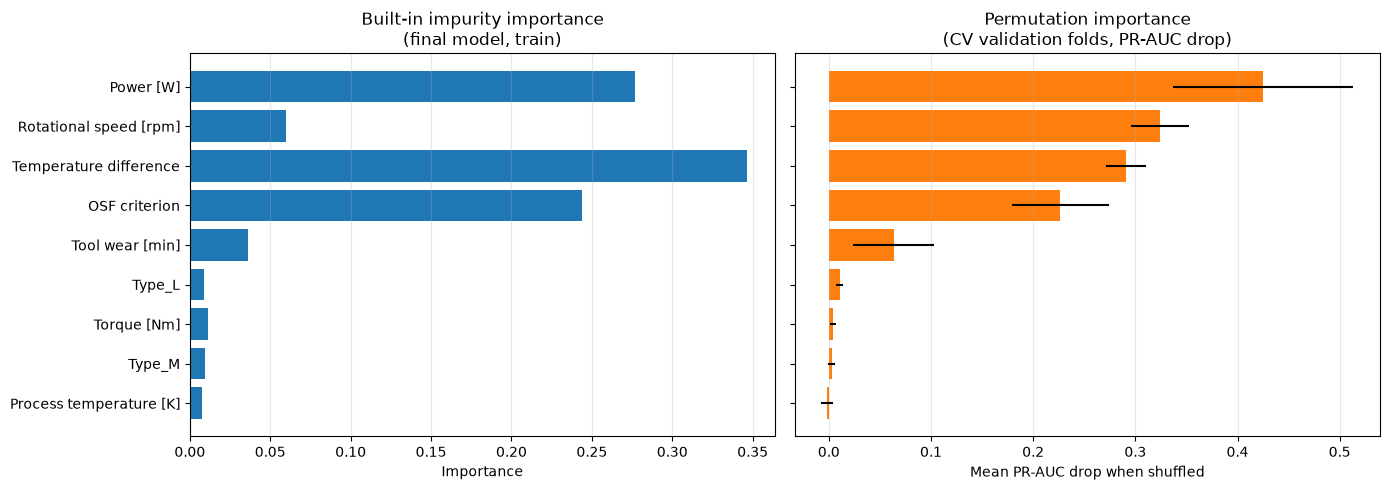

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plot_order = permutation_summary.index[::-1]
axes[0].barh(plot_order, builtin_importances.loc[plot_order], color="tab:blue")
axes[0].set_title("Built-in impurity importance\n(final model, train)")
axes[0].set_xlabel("Importance")

axes[1].barh(
    plot_order,
    permutation_summary.loc[plot_order, "mean_pr_auc_drop"],
    xerr=permutation_summary.loc[plot_order, "std_across_folds"],
    color="tab:orange",
)
axes[1].set_title("Permutation importance\n(CV validation folds, PR-AUC drop)")
axes[1].set_xlabel("Mean PR-AUC drop when shuffled")

for ax in axes:
    ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

### Feature importance interpretation

Both views agree on the same top group: `Power [W]`, `Temperature difference`, `Rotational speed [rpm]` and the `OSF criterion`.

- **The OSF criterion carries real signal.** It ranks third by impurity importance (`0.2437`) and fourth by permutation importance (mean PR-AUC drop `0.2267 ± 0.0475` across folds). This confirms the feature is not a redundant artifact of Tool wear and Torque, and supports keeping it in the final feature set.
- **Raw `Torque [Nm]` contributes almost nothing** (impurity `0.0110`, permutation `0.0037`), which is consistent with the earlier remove-Torque experiment: its information flows through `Power [W]` and the `OSF criterion`.
- **`Process temperature [K]` is a removal candidate.** Its permutation importance is indistinguishable from zero (`-0.0016 ± 0.0056`); the temperature signal is already captured by `Temperature difference`. A controlled experiment like the Torque one could test removing it.
- The two views disagree on `Rotational speed [rpm]` (impurity `0.0598` vs permutation `0.3245`). With correlated features (`Power = rpm * torque * 2*pi/60`), impurity credit concentrates on whichever feature the trees split on first, while shuffling one correlated feature at prediction time creates inconsistent records and can inflate the measured drop. Read the ranking as a group, not as exact per-feature values.
- `Tool wear [min]` keeps a moderate direct contribution (permutation `0.0637`); most of its signal is routed through the `OSF criterion`.

## Experiment: remove raw Torque and Process temperature

The feature-importance analysis flagged `Torque [Nm]` and `Process temperature [K]` as near-zero contributors. Test a reduced feature set that drops both, using the same 5-fold cross-validation as the other experiments. As with the Torque experiment, removing the raw columns does not remove the underlying physical information: torque flows into `Power [W]` and the `OSF criterion`, and the temperature signal is carried by `Temperature difference`.

In [27]:
REDUNDANT_FEATURES = ["Torque [Nm]", "Process temperature [K]"]

X_train_osf_reduced = X_train_osf.drop(columns=REDUNDANT_FEATURES)
X_test_osf_reduced = X_test_osf.drop(columns=REDUNDANT_FEATURES)

reduced_experiment_variants = {
    "Baseline + OSF (9 features)": X_train_osf,
    "Baseline + OSF without Torque (8 features)": X_train_osf_no_torque,
    "Baseline + OSF reduced (7 features)": X_train_osf_reduced,
}

reduced_experiment_rows = []
for feature_variant, X_features in reduced_experiment_variants.items():
    summary, fold_metrics = evaluate_model_with_cv(
        models["Gradient Boosting"],
        X_features,
        y_train,
        cv,
    )
    reduced_experiment_rows.append({
        "feature_variant": feature_variant,
        **summary,
    })

reduced_experiment_results = pd.DataFrame(reduced_experiment_rows)
display(reduced_experiment_results.sort_values("f1_mean", ascending=False))

,feature_variant,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
1,Baseline + OSF without Torque (8 features),0.993625,0.002092,0.960709,0.038533,0.844775,0.086716,0.895611,0.041802,0.991285,0.009802,0.919999,0.039388
0,Baseline + OSF (9 features),0.993625,0.002437,0.965071,0.046764,0.840929,0.085997,0.895381,0.045543,0.990881,0.010406,0.925832,0.039817
2,Baseline + OSF reduced (7 features),0.993250,0.002396,0.952557,0.045945,0.840929,0.085997,0.890018,0.045288,0.991453,0.009310,0.915390,0.050126


In [28]:
reduced_features = X_train_osf_reduced.columns.tolist()
numeric_reduced = [column for column in reduced_features if column not in CATEGORICAL_FEATURES]

X_train_reduced_final = X_train_osf_reduced.copy()
X_test_reduced_final = X_test_osf_reduced.copy()
reduced_scaler = StandardScaler()
X_train_reduced_final[numeric_reduced] = reduced_scaler.fit_transform(X_train_reduced_final[numeric_reduced])
X_test_reduced_final[numeric_reduced] = reduced_scaler.transform(X_test_reduced_final[numeric_reduced])

reduced_model = GradientBoostingClassifier(random_state=42)
reduced_model.fit(X_train_reduced_final, y_train)
reduced_y_proba = reduced_model.predict_proba(X_test_reduced_final)[:, 1]
reduced_y_pred = (reduced_y_proba >= FINAL_THRESHOLD).astype(int)

reduced_metrics = get_metrics(y_test, reduced_y_proba)
reduced_metrics["false_positives"] = ((y_test == 0) & (reduced_y_pred == 1)).sum()
reduced_metrics["false_negatives"] = ((y_test == 1) & (reduced_y_pred == 0)).sum()

reduced_comparison = pd.DataFrame({
    "GB + OSF (9 features)": pd.Series(final_metrics),
    "GB + OSF reduced (7 features)": pd.Series(reduced_metrics),
})
display(reduced_comparison.round(4))

,GB + OSF (9 features),GB + OSF reduced (7 features)
accuracy,0.9945,0.9945
precision,0.9825,0.9825
recall,0.8485,0.8485
f1,0.9106,0.9106
roc_auc,0.9953,0.9951
pr_auc,0.9357,0.9368
false_positives,1.0000,1.0000
false_negatives,10.0000,10.0000


## Why absolute process temperature carries no signal

`Process temperature [K]` looks like essential engineering information, so check what the data actually say: compare the distributions of the absolute temperature and of `Temperature difference` for failing and non-failing records.

Machine failure                      0       1
Process temperature [K] count  7736.00  264.00
                        mean    310.00  310.27
                        std       1.48    1.38
                        min     305.70  306.20
                        25%     308.80  309.48
                        50%     310.00  310.40
                        75%     311.00  311.20
                        max     313.80  313.70
Temperature difference  count  7736.00  264.00
                        mean     10.02    9.38
                        std       0.99    1.16
                        min       7.60    7.60
                        25%       9.30    8.40
                        50%       9.80    9.20
                        75%      11.00   10.30
                        max      12.10   12.00

Correlation Process temperature vs Temperature difference: -0.269
Point-biserial correlation with the target - Process temperature [K]: 0.033
Point-biserial correlation with the target - Temperature difference: -0.114


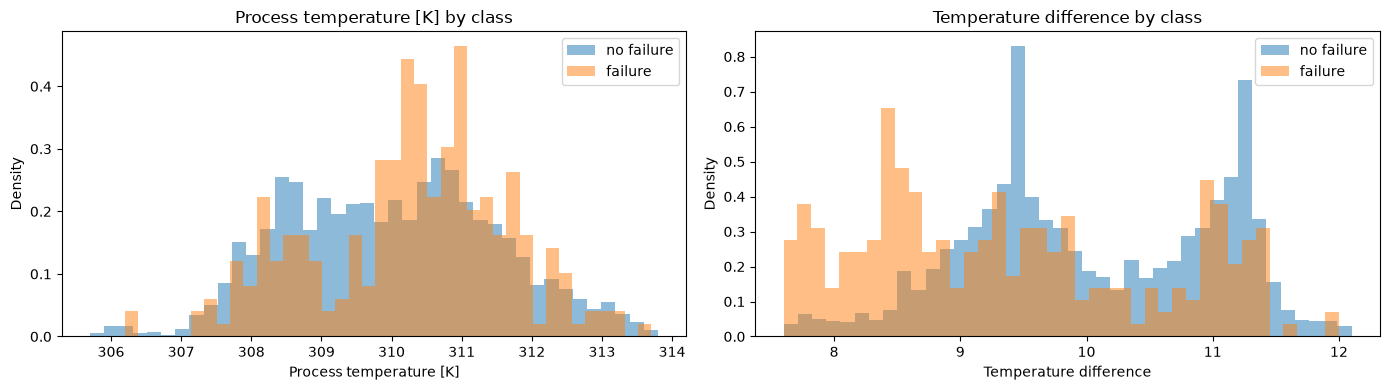

In [29]:
temperature_columns = ["Process temperature [K]", "Temperature difference"]

temperature_stats = X_train_raw[temperature_columns].copy()
temperature_stats["Machine failure"] = y_train
display(
    temperature_stats.groupby("Machine failure")[temperature_columns]
    .describe().round(2).T
)

print(
    "Correlation Process temperature vs Temperature difference:",
    round(X_train_raw["Process temperature [K]"].corr(X_train_raw["Temperature difference"]), 3),
)
for column in temperature_columns:
    print(
        f"Point-biserial correlation with the target - {column}:",
        round(X_train_raw[column].corr(y_train), 3),
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, column in zip(axes, temperature_columns):
    for label, name in [(0, "no failure"), (1, "failure")]:
        subset = X_train_raw.loc[y_train == label, column]
        ax.hist(subset, bins=40, density=True, alpha=0.5, label=name)
    ax.set_title(f"{column} by class")
    ax.set_xlabel(column)
    ax.set_ylabel("Density")
    ax.legend()
plt.tight_layout()
plt.show()

### Interpretation: reduced feature set and the role of temperature

**Reduced feature set.** Dropping raw `Torque [Nm]` and `Process temperature [K]` costs nothing on the development check: the 7-feature model reproduces exactly the same X_test outcome as the 9-feature model (precision `0.9825`, recall `0.8485`, F1 `0.9106`, FP `1`, FN `10`; PR-AUC even marginally higher, `0.9368` vs `0.9357`). In cross-validation the reduced set is marginally weaker (F1 `0.8900` vs `0.8954`, PR-AUC `0.9154` vs `0.9258`) but well within one fold-to-fold standard deviation. The reduced set is a reasonable candidate for the final model: fewer inputs to monitor, no measurable loss.

**Why absolute process temperature carries no signal.** Temperature does matter for failures — but as a *gradient*, not as an absolute level:

- The failing and non-failing records have practically the same absolute process temperature (mean `310.27 K` vs `310.00 K`, heavily overlapping histograms; point-biserial correlation with the target `0.033`).
- `Temperature difference` does separate the classes (failures `9.38 K` vs `10.02 K` on average, correlation `-0.114`): heat-dissipation failures (HDF) happen when the process-to-air difference is *small* (poor heat removal) combined with low rotational speed — the EDA band was `7.6–8.6 K`.
- In this dataset the process temperature is essentially the ambient temperature plus about `10 K` of process heat, so its absolute level mostly tracks ambient drift, which says nothing about the machine's condition. The condition signal is *how well the machine sheds heat relative to its surroundings* — exactly what `Temperature difference` encodes.
- Feature importance is always *conditional*: it measures what a column adds **given the other features**. Once `Temperature difference` is available, `Process temperature [K]` is redundant — the model does not claim temperature is irrelevant, only that the raw column duplicates information the engineered feature already carries.

**Caveat.** This is a property of the AI4I dataset, where ambient temperature varies only about `±2 K`. On a real installation the absolute temperature could carry its own risk (e.g. exceeding material limits), and a model trained on this data would not know that. The conclusion is "redundant given Temperature difference in this data", not "temperature is unimportant in general".

## Final model decision

Closed on 2026-07-19 by `python/final_model.py` (thresholds analysed on out-of-fold probabilities only; X_test used as a development check).

**Model:** `GradientBoostingClassifier(random_state=42)` — confirmed by the hyperparameter comparison above.

**Features (7, reduced set):** `Type_L`, `Type_M`, `Temperature difference`, `Rotational speed [rpm]`, `Power [W]`, `Tool wear [min]`, `OSF criterion` — raw `Torque [Nm]` and `Process temperature [K]` removed after the redundancy experiments above.

**Threshold:** the OOF cost analysis (`results/final_threshold_costs.csv`) shows the optimum is highly sensitive to the assumed FN:FP cost ratio:

```text
FN =  1x FP -> threshold 0.60 (FP 6,  FN 42)
FN =  5-10x -> threshold 0.30 (FP 26, FN 33, precision 0.899, recall 0.875)
FN = 20x    -> threshold 0.15 (FP 43, FN 32)
FN = 30-50x -> threshold 0.05 (FP 206, FN 24)
```

For a typical maintenance setting where a missed failure costs 5-10x more than an unnecessary inspection, the working recommendation is **threshold 0.30** (X_test development check: precision 0.892, recall 0.879, FP 7, FN 8). The default 0.5 remains the choice when false alarms are the binding constraint (X_test: precision 0.983, recall 0.848, FP 1, FN 10). The final call requires real business costs; the saved artifact stores the per-ratio optima so the threshold can be set without retraining.

**Artifacts:** `models/final_model.joblib` (model + scaler + feature list + per-ratio thresholds), `results/final_threshold_costs.csv`, `results/final_model_summary.csv`.

The high-tool-wear operational warning (>= 200 min) analysed above remains a complementary alert layer independent of the model threshold.

**Open items for future work:** validation on truly untouched or future data (X_test was used during exploration), probability calibration if thresholds are to reflect real costs, and monitoring for drift once deployed.